# Module 4: The LLaVA Pattern — Audio Projector + LLM

> *"You don't need to train a 7B model to teach it to listen. You just need to teach it the right language."*

This is Module 4 of the Audio Flamingo 3 series. We now have:
- **Module 1** ✓ — Log Mel Spectrogram: raw audio → `(80, T)`
- **Module 2** ✓ — AF-Whisper Encoder: `(80, T)` → `(1500, 1280)` audio embeddings
- **Module 3** ✓ — CLAP: how audio-text alignment is learned (contrastive pretraining)

Today: **how do we get those 1500 audio embeddings into an LLM?**

**What we'll build:**
1. The dimension mismatch problem — and why a projector solves it
2. The Audio Projector (MLP) from scratch
3. A nano GPT-style LLM that runs on CPU (~10M params)
4. Audio+text interleaving in the context window
5. A complete forward pass: mel → encoder → projector → LLM → logits
6. AF3's 5-stage training curriculum — what freezes, what trains
7. The complete NanoAF3 model in one clean class

**No pretrained weights. No HuggingFace. ~250 lines of pure PyTorch.**

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

plt.style.use('dark_background')
torch.manual_seed(42)

DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.10.0+cpu


---
## Part 1: The Dimension Mismatch Problem

Here is the concrete problem.

AF-Whisper produces audio embeddings of shape `(1500, 1280)` — 1500 time steps, each a 1280-dim vector.

Qwen-2.5 7B has an internal dimension of **3584**. Its token embedding table maps each vocabulary word to a 3584-dim vector.

We want to feed audio embeddings into Qwen as if they were text tokens. But the dimensions don't match.

**The solution is almost embarrassingly simple:** a small MLP that maps 1280 → 3584.

This is the **Audio Projector** — the only component trained from scratch in AF3 (together with the audio encoder finetuning). The LLM itself stays frozen.

/tmp/ipykernel_398/401048781.py:55: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


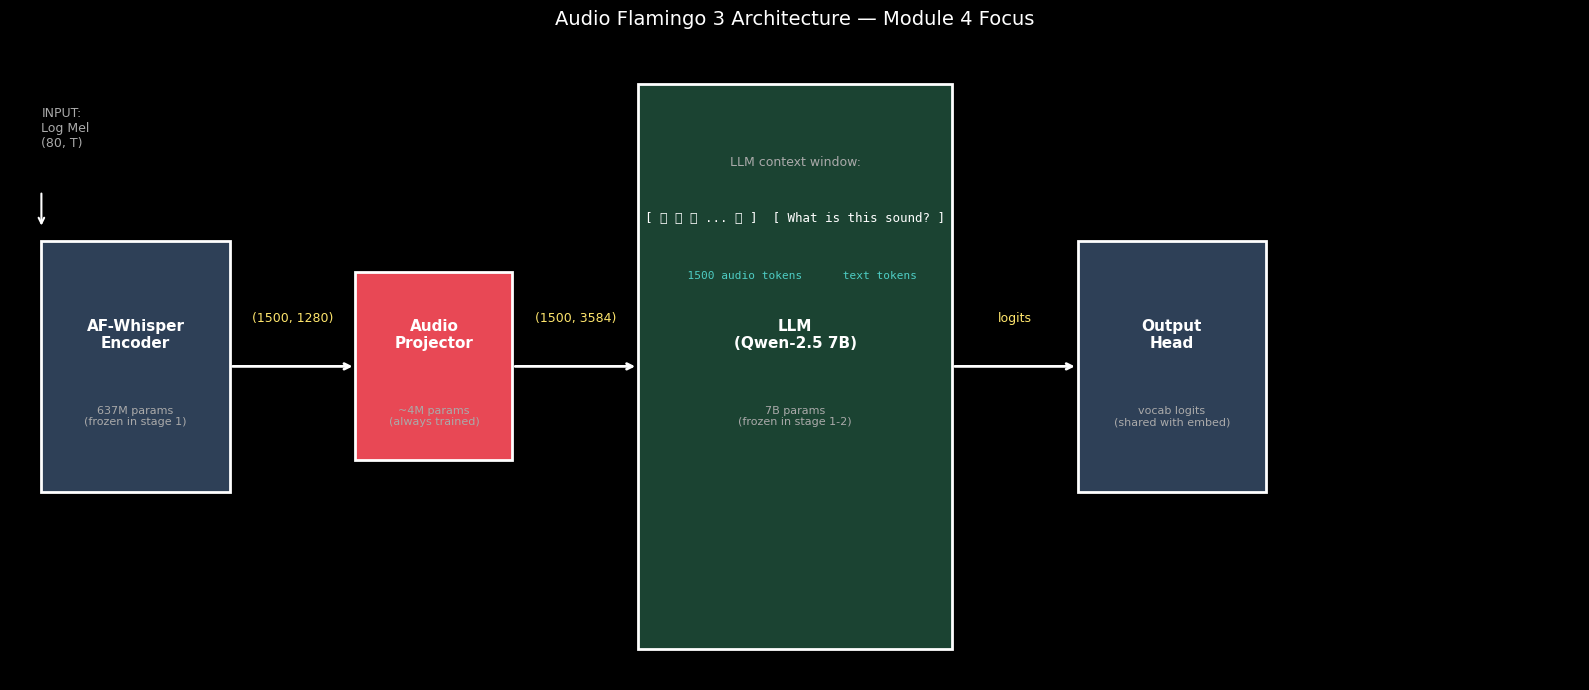

The projector is tiny compared to the rest.
AF-Whisper: 637M  |  Projector: ~4M  |  Qwen 7B: 7000M
Yet the projector is the key that unlocks audio understanding in the LLM.


In [3]:
# --- Visualize the architecture before building it ---

fig, ax = plt.subplots(figsize=(16, 7))
ax.axis('off')

# Draw boxes
boxes = [
    # (x, y, w, h, label, sublabel, color)
    (0.02, 0.3,  0.12, 0.4, 'AF-Whisper\nEncoder', '637M params\n(frozen in stage 1)', '#2E4057'),
    (0.22, 0.35, 0.10, 0.3, 'Audio\nProjector', '~4M params\n(always trained)', '#E84855'),
    (0.40, 0.05, 0.20, 0.9, 'LLM\n(Qwen-2.5 7B)', '7B params\n(frozen in stage 1-2)', '#1B4332'),
    (0.68, 0.3,  0.12, 0.4, 'Output\nHead', 'vocab logits\n(shared with embed)', '#2E4057'),
]

for (x, y, w, h, label, sublabel, color) in boxes:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='white',
                          linewidth=2, transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2 + 0.05, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=11, weight='bold', color='white')
    ax.text(x + w/2, y + h/2 - 0.08, sublabel, transform=ax.transAxes,
            ha='center', va='center', fontsize=8, color='#aaaaaa')

# Arrows with dimension labels
arrows = [
    (0.14, 0.50, 0.08, 0.0,  '(1500, 1280)'),
    (0.32, 0.50, 0.08, 0.0,  '(1500, 3584)'),
    (0.60, 0.50, 0.08, 0.0,  'logits'),
]
for (x, y, dx, dy, label) in arrows:
    ax.annotate('', xy=(x+dx, y+dy), xytext=(x, y),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='white', lw=2))
    ax.text(x + dx/2, y + 0.07, label, transform=ax.transAxes,
            ha='center', fontsize=9, color='#FFE66D')

# Context window detail inside LLM box
ax.text(0.50, 0.82, 'LLM context window:', transform=ax.transAxes,
        ha='center', fontsize=9, color='#aaaaaa')
ax.text(0.50, 0.73, '[ 🔊 🔊 🔊 ... 🔊 ]  [ What is this sound? ]',
        transform=ax.transAxes, ha='center', fontsize=9, color='white',
        fontfamily='monospace')
ax.text(0.50, 0.64, '  1500 audio tokens      text tokens',
        transform=ax.transAxes, ha='center', fontsize=8, color='#4ECDC4',
        fontfamily='monospace')

# Input label
ax.text(0.02, 0.85, 'INPUT:\nLog Mel\n(80, T)', transform=ax.transAxes,
        ha='left', fontsize=9, color='#aaaaaa')
ax.annotate('', xy=(0.02, 0.72), xytext=(0.02, 0.78),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

ax.set_title('Audio Flamingo 3 Architecture — Module 4 Focus', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print('The projector is tiny compared to the rest.')
print('AF-Whisper: 637M  |  Projector: ~4M  |  Qwen 7B: 7000M')
print('Yet the projector is the key that unlocks audio understanding in the LLM.')

---
## Part 2: The Audio Projector

AF3 uses a 2-layer MLP with GELU activation. Applied **independently to each of the 1500 time steps** — like a 1×1 convolution across the sequence.

This is sometimes called an **"adapter"** or **"connector"** in the multimodal literature. The LLaVA paper called it a "linear projection" — AF3 uses a small MLP for more expressiveness.

In [4]:
# --- Audio Projector ---

class AudioProjector(nn.Module):
    """
    Maps AF-Whisper audio embeddings to LLM input dimension.
    Applied position-wise: each of the 1500 time steps is projected independently.

    AF3 real dimensions:  audio_dim=1280  →  llm_dim=3584  (Qwen-2.5 7B)
    Our nano dimensions:  audio_dim=64    →  llm_dim=256

    Input:  (batch, seq_len, audio_dim)
    Output: (batch, seq_len, llm_dim)
    """
    def __init__(self, audio_dim: int, llm_dim: int):
        super().__init__()
        # 2-layer MLP with hidden dim = llm_dim
        # Simple but effective — this is exactly AF3's projector design
        self.fc1  = nn.Linear(audio_dim, llm_dim)
        self.act  = nn.GELU()
        self.fc2  = nn.Linear(llm_dim, llm_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, audio_dim)
        x = self.act(self.fc1(x))   # (batch, seq_len, llm_dim)
        x = self.fc2(x)             # (batch, seq_len, llm_dim)
        return x


# Dimensions for our nano model
AUDIO_DIM  = 64     # our nano AF-Whisper output dim (Module 2)
LLM_DIM    = 256    # our nano LLM's embedding dim
N_AUDIO_TOKENS = 50 # use 50 audio tokens for speed (real: 1500)

projector = AudioProjector(audio_dim=AUDIO_DIM, llm_dim=LLM_DIM)

# Simulate encoder output
fake_audio_emb = torch.randn(1, N_AUDIO_TOKENS, AUDIO_DIM)  # (B, 50, 64)
projected = projector(fake_audio_emb)

print('--- AudioProjector ---')
print(f'Input:  {fake_audio_emb.shape}  (batch, audio_tokens, audio_dim)')
print(f'Output: {projected.shape}  (batch, audio_tokens, llm_dim)')

n_proj = sum(p.numel() for p in projector.parameters())
print(f'\nNano projector params:  {n_proj:,}')

# Real AF3 projector
proj_real = AudioProjector(1280, 3584)
n_proj_real = sum(p.numel() for p in proj_real.parameters())
print(f'Real AF3 projector params: {n_proj_real:,}  (~{n_proj_real/1e6:.1f}M)')
print(f'  → {n_proj_real/7e9*100:.2f}% of Qwen 7B size — truly tiny')
del proj_real

--- AudioProjector ---
Input:  torch.Size([1, 50, 64])  (batch, audio_tokens, audio_dim)
Output: torch.Size([1, 50, 256])  (batch, audio_tokens, llm_dim)

Nano projector params:  82,432
Real AF3 projector params: 17,439,744  (~17.4M)
  → 0.25% of Qwen 7B size — truly tiny


---
## Part 3: The Nano LLM

We need an LLM to receive the projected audio tokens. We'll build a **GPT-style autoregressive decoder** from scratch.

Qwen-2.5 uses Grouped Query Attention (GQA) and RoPE positional embeddings — we'll use standard Multi-Head Attention and learned positional embeddings to keep things clear. The principle is identical.

**Key property:** the LLM treats audio tokens and text tokens identically once they're projected to `llm_dim`. It doesn't know or care whether a token came from audio or from the vocabulary table — they all look the same inside the transformer.

In [5]:
# --- Nano GPT-style LLM ---
# We reuse the transformer building blocks from Module 2
# but now it's a DECODER (causal/autoregressive) not an encoder

class CausalSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention with causal mask.

    The causal mask ensures token i can only attend to tokens 0..i
    (no peeking at future tokens during generation).

    In the encoder (Module 2): no mask — all tokens see all tokens.
    In the decoder (LLM):      causal mask — each token sees only past tokens.
    """
    def __init__(self, d_model: int, n_heads: int, max_seq_len: int):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

        # Causal mask: lower triangular matrix
        # register_buffer: not a parameter (no gradient), but saved with model
        mask = torch.tril(torch.ones(max_seq_len, max_seq_len))
        self.register_buffer('mask', mask.view(1, 1, max_seq_len, max_seq_len))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape

        # Project to Q, K, V in one shot and split
        qkv = self.qkv_proj(x)                          # (B, T, 3*D)
        Q, K, V = qkv.split(self.d_model, dim=-1)       # each: (B, T, D)

        # Reshape to heads
        def to_heads(t):
            return t.view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # (B, H, T, d_k)
        Q, K, V = to_heads(Q), to_heads(K), to_heads(V)

        # Scaled dot-product attention
        scores  = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B, H, T, T)

        # Apply causal mask: set future positions to -inf before softmax
        scores  = scores.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        weights = F.softmax(scores, dim=-1)   # (B, H, T, T) — future positions = 0

        out = torch.matmul(weights, V)        # (B, H, T, d_k)
        out = out.transpose(1, 2).contiguous().view(B, T, D)  # (B, T, D)
        return self.out_proj(out)


class LLMBlock(nn.Module):
    """One GPT-style decoder block: CausalMHSA + FFN + Pre-Norm + Residuals."""
    def __init__(self, d_model: int, n_heads: int, max_seq_len: int):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = CausalSelfAttention(d_model, n_heads, max_seq_len)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class NanoLLM(nn.Module):
    """
    A tiny GPT-style autoregressive language model.

    This represents Qwen-2.5 7B in our pipeline.
    The architecture is functionally identical — just much smaller.

    Key insight: this model accepts BOTH text tokens (via embedding table)
    AND pre-projected audio embeddings (bypassing the embedding table).
    That's the LLaVA trick.
    """
    def __init__(self,
                 vocab_size:  int,
                 d_model:     int,
                 n_heads:     int,
                 n_layers:    int,
                 max_seq_len: int):
        super().__init__()
        self.d_model     = d_model
        self.max_seq_len = max_seq_len

        # Text token embedding table
        self.token_embed = nn.Embedding(vocab_size, d_model)
        # Positional embeddings (covers both audio + text positions)
        self.pos_embed   = nn.Embedding(max_seq_len, d_model)

        # Transformer decoder blocks
        self.blocks = nn.ModuleList([
            LLMBlock(d_model, n_heads, max_seq_len)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

        # Output head: map d_model → vocab_size (tied with token_embed in Qwen)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying: output head shares weights with token embedding
        # Standard in modern LLMs — saves params, improves performance
        self.lm_head.weight = self.token_embed.weight

    def embed_text(self, token_ids: torch.Tensor) -> torch.Tensor:
        """Convert text token IDs to embeddings. Shape: (B, T_text) → (B, T_text, D)"""
        return self.token_embed(token_ids)

    def forward_from_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass starting from pre-computed embeddings.
        Used when we've already interleaved audio + text embeddings.

        Input:  (B, total_seq_len, d_model)  — audio + text tokens mixed
        Output: (B, total_seq_len, vocab_size) — logits
        """
        B, T, D = x.shape
        assert T <= self.max_seq_len, f'Sequence too long: {T} > {self.max_seq_len}'

        # Add positional embeddings
        positions = torch.arange(T, device=x.device)
        x = x + self.pos_embed(positions)  # (B, T, D)

        # Pass through all transformer blocks
        for block in self.blocks:
            x = block(x)

        x = self.norm(x)          # (B, T, D)
        logits = self.lm_head(x)  # (B, T, vocab_size)
        return logits

    def forward(self, token_ids: torch.Tensor) -> torch.Tensor:
        """Standard text-only forward pass. Input: (B, T) token IDs."""
        x = self.embed_text(token_ids)       # (B, T, D)
        return self.forward_from_embeddings(x)


# --- Instantiate nano LLM ---
VOCAB_SIZE  = 256    # tiny vocabulary (real Qwen: 151,936 tokens)
N_HEADS_LLM = 4
N_LAYERS    = 4
MAX_SEQ_LEN = N_AUDIO_TOKENS + 64  # audio tokens + some text tokens

llm = NanoLLM(
    vocab_size  = VOCAB_SIZE,
    d_model     = LLM_DIM,      # 256
    n_heads     = N_HEADS_LLM,
    n_layers    = N_LAYERS,
    max_seq_len = MAX_SEQ_LEN,
)

n_llm = sum(p.numel() for p in llm.parameters())
print(f'Nano LLM parameters: {n_llm:,}  (~{n_llm/1e6:.1f}M)')
print(f'(Real Qwen-2.5 7B: ~7,600,000,000 params)')
print(f'\nBreakdown:')
print(f'  Token embedding:  {VOCAB_SIZE * LLM_DIM:,}')
print(f'  Pos embedding:    {MAX_SEQ_LEN * LLM_DIM:,}')
n_per_block = sum(p.numel() for p in llm.blocks[0].parameters())
print(f'  Per LLM block:    {n_per_block:,}  × {N_LAYERS} blocks')
print(f'  LM head:          (tied with token embed, no extra params)')

Nano LLM parameters: 3,250,176  (~3.3M)
(Real Qwen-2.5 7B: ~7,600,000,000 params)

Breakdown:
  Token embedding:  65,536
  Pos embedding:    29,184
  Per LLM block:    788,736  × 4 blocks
  LM head:          (tied with token embed, no extra params)


---
## Part 4: Audio + Text Interleaving

This is the LLaVA trick. Inside the LLM, audio tokens and text tokens are indistinguishable — they're both just vectors of size `d_model`.

The sequence looks like this:

```
[ <audio>  🔊 🔊 🔊 ... 🔊  </audio>  "What is this sound?" ]
  special   1500 audio tokens  special   text tokens
  token     (from projector)   token     (from vocab table)
```

The LLM then autoregressively generates the answer, attending to all previous tokens — both audio and text.

--- Multimodal Input ---
Audio tokens:     50 (+ 2 special tokens)
Text tokens:      19  ("What is this sound?")
Total sequence:   71 tokens
Embedding shape:  torch.Size([1, 71, 256])



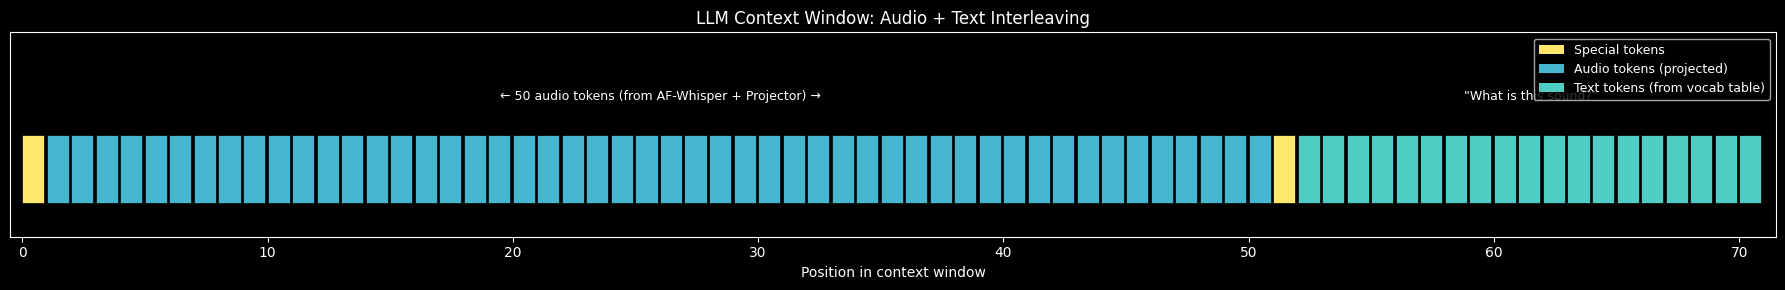

Inside the LLM, audio tokens and text tokens are identical in format.
The causal mask lets the LLM attend to all audio tokens when generating text.


In [6]:
# --- Audio + Text Interleaving ---

# Simple tokenizer for our nano model
# In real AF3: tiktoken / Qwen's BPE tokenizer with 151,936 tokens
CHAR_TO_ID = {chr(i): i for i in range(VOCAB_SIZE)}
ID_TO_CHAR = {i: chr(i) for i in range(VOCAB_SIZE)}

# Special token IDs
AUDIO_START_ID = 1
AUDIO_END_ID   = 2
PAD_ID         = 0

def tokenize_text(text: str) -> torch.Tensor:
    """Simple character-level tokenizer."""
    ids = [CHAR_TO_ID.get(c, 63) for c in text]  # 63 = '?' for unknowns
    return torch.tensor(ids, dtype=torch.long)


def build_multimodal_input(audio_embeddings: torch.Tensor,
                           text: str,
                           llm: NanoLLM,
                           projector: AudioProjector) -> dict:
    """
    Build the interleaved audio+text input for the LLM.

    This is the core of the LLaVA pattern:
    1. Project audio embeddings to LLM dim
    2. Embed special tokens and text tokens
    3. Concatenate: [<audio>] + [audio_tokens] + [</audio>] + [text_tokens]

    Args:
        audio_embeddings: (1, n_audio_tokens, audio_dim) — from AF-Whisper
        text: the question/prompt text
        llm: the language model
        projector: the audio projector MLP

    Returns:
        dict with 'embeddings' (for forward pass) and metadata
    """
    B = audio_embeddings.shape[0]
    assert B == 1, 'This demo handles batch size 1'

    # 1. Project audio: (1, n_audio, audio_dim) → (1, n_audio, llm_dim)
    audio_proj = projector(audio_embeddings)   # (1, 50, 256)

    # 2. Special token embeddings
    audio_start = llm.embed_text(
        torch.tensor([[AUDIO_START_ID]])
    )  # (1, 1, 256)
    audio_end = llm.embed_text(
        torch.tensor([[AUDIO_END_ID]])
    )  # (1, 1, 256)

    # 3. Text token embeddings
    text_ids    = tokenize_text(text)                  # (T_text,)
    text_embeds = llm.embed_text(text_ids.unsqueeze(0))  # (1, T_text, 256)

    # 4. Concatenate all along the sequence dimension
    # Final sequence: <audio> | audio_tokens | </audio> | text_tokens
    full_sequence = torch.cat([
        audio_start,    # (1, 1, 256)
        audio_proj,     # (1, 50, 256)
        audio_end,      # (1, 1, 256)
        text_embeds,    # (1, T_text, 256)
    ], dim=1)           # (1, 52 + T_text, 256)

    n_audio_tokens = audio_proj.shape[1]
    n_text_tokens  = text_embeds.shape[1]
    total_tokens   = full_sequence.shape[1]

    return {
        'embeddings':     full_sequence,
        'n_audio_tokens': n_audio_tokens,
        'n_text_tokens':  n_text_tokens,
        'total_tokens':   total_tokens,
        'text_ids':       text_ids,
    }


# --- Test the interleaving ---
projector = AudioProjector(audio_dim=AUDIO_DIM, llm_dim=LLM_DIM)
fake_audio = torch.randn(1, N_AUDIO_TOKENS, AUDIO_DIM)
question   = "What is this sound?"

with torch.no_grad():
    mm_input = build_multimodal_input(fake_audio, question, llm, projector)

print('--- Multimodal Input ---')
print(f'Audio tokens:     {mm_input["n_audio_tokens"]} (+ 2 special tokens)')
print(f'Text tokens:      {mm_input["n_text_tokens"]}  ("{question}")')
print(f'Total sequence:   {mm_input["total_tokens"]} tokens')
print(f'Embedding shape:  {mm_input["embeddings"].shape}')
print()

# Visualize the token sequence
fig, ax = plt.subplots(figsize=(18, 3))

total = mm_input['total_tokens']
# Color: special=yellow, audio=blue, text=green
token_colors = (['#FFE66D'] +                              # <audio>
                ['#45B7D1'] * mm_input['n_audio_tokens'] + # audio tokens
                ['#FFE66D'] +                              # </audio>
                ['#4ECDC4'] * mm_input['n_text_tokens'])   # text tokens

for i, color in enumerate(token_colors):
    rect = plt.Rectangle((i, 0), 0.9, 1, facecolor=color, edgecolor='black', lw=0.5)
    ax.add_patch(rect)

ax.set_xlim(-0.5, total + 0.5)
ax.set_ylim(-0.5, 2.5)
ax.set_yticks([])
ax.set_xlabel('Position in context window')

# Labels
ax.text(0.5, 1.5, '<audio>', ha='center', fontsize=7, color='black', weight='bold')
ax.text(mm_input['n_audio_tokens']/2 + 1, 1.5,
        f'← {mm_input["n_audio_tokens"]} audio tokens (from AF-Whisper + Projector) →',
        ha='center', fontsize=9, color='white')
ax.text(mm_input['n_audio_tokens'] + 1.5, 1.5, '</audio>', ha='center', fontsize=7,
        color='black', weight='bold')
ax.text(mm_input['n_audio_tokens'] + 2 + mm_input['n_text_tokens']/2, 1.5,
        f'"{question}"', ha='center', fontsize=9, color='white')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#FFE66D', label='Special tokens'),
                Patch(facecolor='#45B7D1', label='Audio tokens (projected)'),
                Patch(facecolor='#4ECDC4', label='Text tokens (from vocab table)')]
ax.legend(handles=legend_elems, loc='upper right', fontsize=9)
ax.set_title('LLM Context Window: Audio + Text Interleaving', fontsize=12)
plt.tight_layout()
plt.show()

print('Inside the LLM, audio tokens and text tokens are identical in format.')
print('The causal mask lets the LLM attend to all audio tokens when generating text.')

---
## Part 5: The Complete Forward Pass

Now let's run the full pipeline end-to-end: raw audio → encoder → projector → LLM → logits.

In [7]:
# --- Full pipeline components from Module 2 ---
# (Pasting the key pieces to keep the notebook self-contained)

def hz_to_mel(hz): return 2595.0 * np.log10(1.0 + hz / 700.0)
def mel_to_hz(mel): return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

def build_mel_filterbank(n_mels, n_fft, sample_rate):
    fmax = sample_rate / 2.0
    mel_pts = np.linspace(hz_to_mel(0), hz_to_mel(fmax), n_mels + 2)
    hz_pts  = mel_to_hz(mel_pts)
    n_freqs = n_fft // 2 + 1
    bins    = np.floor((n_fft + 1) * hz_pts / sample_rate).astype(int)
    fb      = np.zeros((n_mels, n_freqs))
    for m in range(1, n_mels + 1):
        fl, fc, fr = bins[m-1], bins[m], bins[m+1]
        for k in range(fl, fc): fb[m-1, k] = (k-fl)/(fc-fl+1e-8)
        for k in range(fc, fr): fb[m-1, k] = (fr-k)/(fr-fc+1e-8)
    return fb

def log_mel_spectrogram(audio, sr=16000, n_fft=400, hop=160, n_mels=80):
    win    = np.hanning(n_fft)
    nf     = 1 + (len(audio) - n_fft) // hop
    ps     = np.zeros((n_fft//2+1, nf))
    for i in range(nf):
        frame  = audio[i*hop:i*hop+n_fft] * win
        ps[:,i] = np.abs(np.fft.rfft(frame))**2
    fb  = build_mel_filterbank(n_mels, n_fft, sr)
    mel = np.log10(np.maximum(fb @ ps, 1e-10))
    mel = np.maximum(mel, mel.max() - 8.0)
    return (mel + 4.0) / 4.0


# Nano WhisperEncoder (from Module 2, condensed)
class ConvStem(nn.Module):
    def __init__(self, n_mels, d_model):
        super().__init__()
        self.c1 = nn.Conv1d(n_mels, d_model, 3, padding=1)
        self.c2 = nn.Conv1d(d_model, d_model, 3, stride=2, padding=1)
    def forward(self, x):
        return F.gelu(self.c2(F.gelu(self.c1(x))))

class EncoderBlock(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.n1   = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, h, batch_first=True)
        self.n2   = nn.LayerNorm(d)
        self.ffn  = nn.Sequential(nn.Linear(d, d*4), nn.GELU(), nn.Linear(d*4, d))
    def forward(self, x):
        a, _ = self.attn(self.n1(x), self.n1(x), self.n1(x))
        x = x + a
        return x + self.ffn(self.n2(x))

class NanoWhisperEncoder(nn.Module):
    def __init__(self, n_mels=80, d_model=64, n_heads=4, n_layers=2, n_pos=200):
        super().__init__()
        self.stem   = ConvStem(n_mels, d_model)
        self.pe     = nn.Embedding(n_pos, d_model)
        self.blocks = nn.ModuleList([EncoderBlock(d_model, n_heads) for _ in range(n_layers)])
        self.norm   = nn.LayerNorm(d_model)
    def forward(self, mel):
        x = self.stem(mel).transpose(1, 2)                    # (B, T//2, d_model)
        x = x + self.pe(torch.arange(x.shape[1]))             # + pos embed
        for b in self.blocks: x = b(x)
        return self.norm(x)                                    # (B, T//2, d_model)


# --- Complete NanoAF3 model ---

class NanoAF3(nn.Module):
    """
    Audio Flamingo 3 — Nano Edition.

    Faithful to AF3's architecture in all the important ways:
    - Audio encoder (AF-Whisper style)
    - Audio projector (MLP)
    - Autoregressive LLM
    - Audio+text interleaving in context window

    Just much smaller: fits on CPU, trains in seconds.
    """
    def __init__(self,
                 n_mels=80, audio_dim=64, audio_heads=4, audio_layers=2,
                 llm_dim=256, llm_heads=4, llm_layers=4,
                 vocab_size=256, max_text_len=64,
                 n_audio_tokens=50):
        super().__init__()

        self.n_audio_tokens = n_audio_tokens
        max_seq = n_audio_tokens + 2 + max_text_len  # +2 for special tokens

        # Component 1: Audio Encoder (AF-Whisper)
        self.audio_encoder = NanoWhisperEncoder(
            n_mels=n_mels, d_model=audio_dim,
            n_heads=audio_heads, n_layers=audio_layers,
            n_pos=n_audio_tokens + 10
        )

        # Component 2: Audio Projector
        self.projector = AudioProjector(audio_dim=audio_dim, llm_dim=llm_dim)

        # Component 3: LLM
        self.llm = NanoLLM(
            vocab_size=vocab_size, d_model=llm_dim,
            n_heads=llm_heads, n_layers=llm_layers,
            max_seq_len=max_seq
        )

        # Special token IDs
        self.AUDIO_START = AUDIO_START_ID
        self.AUDIO_END   = AUDIO_END_ID

    def forward(self, mel: torch.Tensor, text_ids: torch.Tensor) -> torch.Tensor:
        """
        Full forward pass.

        Args:
            mel:      (B, 80, T_mel)   — Log Mel Spectrogram
            text_ids: (B, T_text)      — tokenized question
        Returns:
            logits:   (B, total_seq, vocab_size)
        """
        B = mel.shape[0]

        # ── Stage 1: Audio Encoding ──────────────────────────────────────────
        audio_emb = self.audio_encoder(mel)         # (B, T_audio, audio_dim)

        # Trim or pad to fixed n_audio_tokens
        T_a = audio_emb.shape[1]
        if T_a > self.n_audio_tokens:
            audio_emb = audio_emb[:, :self.n_audio_tokens, :]
        elif T_a < self.n_audio_tokens:
            pad = torch.zeros(B, self.n_audio_tokens - T_a, audio_emb.shape[2])
            audio_emb = torch.cat([audio_emb, pad], dim=1)

        # ── Stage 2: Audio Projection ─────────────────────────────────────────
        audio_proj = self.projector(audio_emb)      # (B, n_audio_tokens, llm_dim)

        # ── Stage 3: Build interleaved sequence ───────────────────────────────
        # Special token embeddings
        start_tok = torch.full((B, 1), self.AUDIO_START, dtype=torch.long)
        end_tok   = torch.full((B, 1), self.AUDIO_END,   dtype=torch.long)
        start_emb = self.llm.embed_text(start_tok)  # (B, 1, llm_dim)
        end_emb   = self.llm.embed_text(end_tok)    # (B, 1, llm_dim)
        text_emb  = self.llm.embed_text(text_ids)   # (B, T_text, llm_dim)

        # Concatenate: [<audio>] + audio_tokens + [</audio>] + text_tokens
        full_seq = torch.cat([start_emb, audio_proj, end_emb, text_emb], dim=1)

        # ── Stage 4: LLM forward ──────────────────────────────────────────────
        logits = self.llm.forward_from_embeddings(full_seq)  # (B, total, vocab_size)
        return logits


# --- Build and test ---
model = NanoAF3(
    n_mels=80, audio_dim=AUDIO_DIM, audio_heads=4, audio_layers=2,
    llm_dim=LLM_DIM, llm_heads=N_HEADS_LLM, llm_layers=N_LAYERS,
    vocab_size=VOCAB_SIZE, max_text_len=64, n_audio_tokens=N_AUDIO_TOKENS
)

# Create test inputs
SR = 16_000
t  = np.linspace(0, 1.0, SR, endpoint=False)
test_waveform = 0.5 * np.sin(2*np.pi*440*t)
test_mel  = log_mel_spectrogram(test_waveform)
mel_t     = torch.tensor(test_mel, dtype=torch.float32).unsqueeze(0)  # (1, 80, T)
text_ids  = tokenize_text("What is this sound?").unsqueeze(0)         # (1, T_text)

with torch.no_grad():
    logits = model(mel_t, text_ids)

total_seq = 1 + N_AUDIO_TOKENS + 1 + text_ids.shape[1]
print('=== NanoAF3 Forward Pass ===')
print(f'Input mel:      {mel_t.shape}')
print(f'Input text:     {text_ids.shape}  ("{question}")')
print(f'Output logits:  {logits.shape}')
print(f'  = (batch=1, seq_len={total_seq}, vocab={VOCAB_SIZE})')
print()

# Show total parameters
n_total = sum(p.numel() for p in model.parameters())
n_enc   = sum(p.numel() for p in model.audio_encoder.parameters())
n_proj  = sum(p.numel() for p in model.projector.parameters())
n_llm   = sum(p.numel() for p in model.llm.parameters())
print(f'Total NanoAF3 params:   {n_total:,}')
print(f'  Audio encoder:        {n_enc:,}  ({n_enc/n_total*100:.1f}%)')
print(f'  Projector:            {n_proj:,}  ({n_proj/n_total*100:.1f}%)')
print(f'  LLM:                  {n_llm:,}  ({n_llm/n_total*100:.1f}%)')

=== NanoAF3 Forward Pass ===
Input mel:      torch.Size([1, 80, 98])
Input text:     torch.Size([1, 19])  ("What is this sound?")
Output logits:  torch.Size([1, 71, 256])
  = (batch=1, seq_len=71, vocab=256)

Total NanoAF3 params:   3,464,832
  Audio encoder:        131,712  (3.8%)
  Projector:            82,432  (2.4%)
  LLM:                  3,250,688  (93.8%)


---
## Part 6: AF3's 5-Stage Training Curriculum

AF3 doesn't train all components at once. It uses a **5-stage curriculum** — each stage unfreezes more parameters and uses harder tasks.

This is crucial for stability: if you train everything at once from random init, the gradients from the LLM destroy the carefully pretrained audio encoder.

In [8]:
# --- 5-Stage Training Curriculum ---

def freeze(module: nn.Module):
    """Freeze all parameters — no gradient updates."""
    for p in module.parameters():
        p.requires_grad = False

def unfreeze(module: nn.Module):
    """Unfreeze all parameters — allow gradient updates."""
    for p in module.parameters():
        p.requires_grad = True

def count_trainable(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


stages = [
    {
        'name':     'Stage 1: Projector Warmup',
        'freeze':   ['audio_encoder', 'llm'],
        'unfreeze': ['projector'],
        'data':     'Large-scale audio captioning (~8M pairs)',
        'task':     'Audio description generation',
        'why':      'Teach projector to translate audio → LLM space.\n'
                    'LLM and encoder stay frozen so they don\'t get corrupted.\n'
                    'Only ~4M params trained — very stable.',
    },
    {
        'name':     'Stage 2: Encoder + Projector Finetuning',
        'freeze':   ['llm'],
        'unfreeze': ['audio_encoder', 'projector'],
        'data':     'AudioSkills-XL (8M QA pairs)',
        'task':     'Audio QA across all 3 modalities',
        'why':      'Now finetune the encoder on diverse audio tasks.\n'
                    'LLM still frozen — projector acts as a buffer.\n'
                    'Encoder learns to produce task-relevant features.',
    },
    {
        'name':     'Stage 3: Full Model Finetuning',
        'freeze':   [],
        'unfreeze': ['audio_encoder', 'projector', 'llm'],
        'data':     'AudioSkills-XL + LongAudio-XL (1.25M long-audio QA)',
        'task':     'All audio tasks including long-form audio',
        'why':      'Everything unfrozen — joint optimization.\n'
                    'LR very low for LLM (don\'t destroy language ability).\n'
                    'Introduces long audio: sliding window over 10-min clips.',
    },
    {
        'name':     'Stage 4: Chain-of-Thought (AF-Think)',
        'freeze':   ['audio_encoder', 'projector'],
        'unfreeze': ['llm'],
        'data':     'AF-Think dataset (250K CoT pairs)',
        'task':     'Step-by-step audio reasoning',
        'why':      'Teach the LLM to reason before answering.\n'
                    'Audio representations already good — focus on LLM behavior.\n'
                    'CoT format: <think>...reasoning...</think> Answer: ...',
    },
    {
        'name':     'Stage 5: Instruction Tuning (AF-Chat)',
        'freeze':   ['audio_encoder'],
        'unfreeze': ['projector', 'llm'],
        'data':     'AF-Chat dataset (75K multi-turn dialogues)',
        'task':     'Multi-turn conversation about audio',
        'why':      'Final polish: teach the model to follow instructions.\n'
                    'Multi-turn format: user/assistant/user/assistant...\n'
                    'This produces the final AF3 chat model.',
    },
]

print('AF3 Five-Stage Training Curriculum\n')
print('=' * 70)

for i, stage in enumerate(stages):
    # Apply freeze/unfreeze
    for name in stage['freeze']:
        freeze(getattr(model, name))
    for name in stage['unfreeze']:
        unfreeze(getattr(model, name))

    n_train = count_trainable(model)
    pct     = n_train / n_total * 100

    enc_grad  = any(p.requires_grad for p in model.audio_encoder.parameters())
    proj_grad = any(p.requires_grad for p in model.projector.parameters())
    llm_grad  = any(p.requires_grad for p in model.llm.parameters())

    print(f'\n{stage["name"]}')
    print(f'  Trainable params: {n_train:,} / {n_total:,}  ({pct:.1f}%)')
    print(f'  Audio Encoder: {"TRAIN" if enc_grad  else "frozen":6}  '
          f'Projector: {"TRAIN" if proj_grad else "frozen":6}  '
          f'LLM: {"TRAIN" if llm_grad  else "frozen"}')
    print(f'  Data: {stage["data"]}')
    print(f'  Task: {stage["task"]}')
    print(f'  Why:')
    for line in stage['why'].split('\n'):
        print(f'    {line}')

print('\n' + '=' * 70)

AF3 Five-Stage Training Curriculum


Stage 1: Projector Warmup
  Trainable params: 82,432 / 3,464,832  (2.4%)
  Audio Encoder: frozen  Projector: TRAIN   LLM: frozen
  Data: Large-scale audio captioning (~8M pairs)
  Task: Audio description generation
  Why:
    Teach projector to translate audio → LLM space.
    LLM and encoder stay frozen so they don't get corrupted.
    Only ~4M params trained — very stable.

Stage 2: Encoder + Projector Finetuning
  Trainable params: 214,144 / 3,464,832  (6.2%)
  Audio Encoder: TRAIN   Projector: TRAIN   LLM: frozen
  Data: AudioSkills-XL (8M QA pairs)
  Task: Audio QA across all 3 modalities
  Why:
    Now finetune the encoder on diverse audio tasks.
    LLM still frozen — projector acts as a buffer.
    Encoder learns to produce task-relevant features.

Stage 3: Full Model Finetuning
  Trainable params: 3,464,832 / 3,464,832  (100.0%)
  Audio Encoder: TRAIN   Projector: TRAIN   LLM: TRAIN
  Data: AudioSkills-XL + LongAudio-XL (1.25M long-audio QA

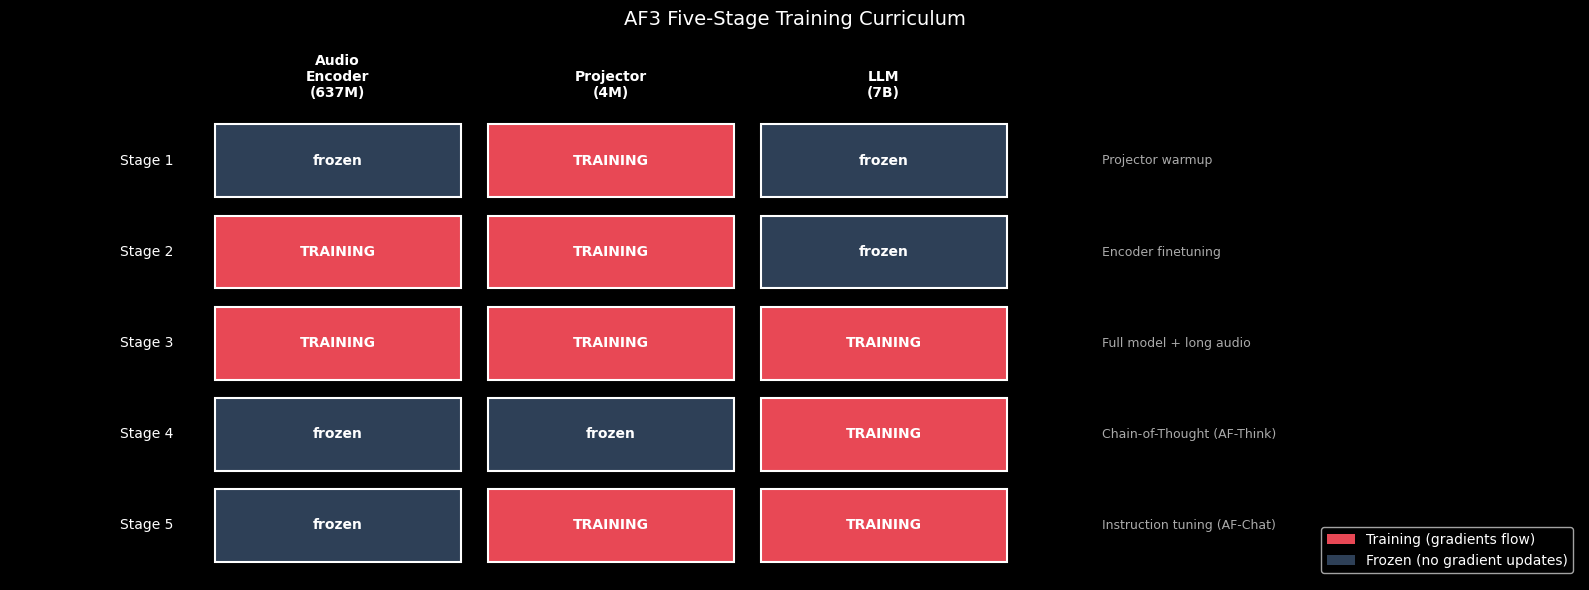

In [9]:
# --- Visualize the 5-stage curriculum ---

fig, ax = plt.subplots(figsize=(16, 6))

components = ['Audio\nEncoder\n(637M)', 'Projector\n(4M)', 'LLM\n(7B)']
stage_names = [f'Stage {i+1}' for i in range(5)]

# Trainable = True/False for each (stage, component)
grid = [
    [False, True,  False],   # Stage 1
    [True,  True,  False],   # Stage 2
    [True,  True,  True ],   # Stage 3
    [False, False, True ],   # Stage 4
    [False, True,  True ],   # Stage 5
]

for i, row in enumerate(grid):
    for j, trainable in enumerate(row):
        color = '#E84855' if trainable else '#2E4057'
        label = 'TRAINING' if trainable else 'frozen'
        rect  = plt.Rectangle((j*2, 4-i), 1.8, 0.8,
                               facecolor=color, edgecolor='white', lw=1.5)
        ax.add_patch(rect)
        ax.text(j*2 + 0.9, 4-i + 0.4, label,
                ha='center', va='center', fontsize=10, color='white', weight='bold')

# Labels
for j, comp in enumerate(components):
    ax.text(j*2 + 0.9, 5.1, comp, ha='center', fontsize=10, color='white', weight='bold')
for i, name in enumerate(stage_names):
    ax.text(-0.3, 4-i + 0.4, name, ha='right', va='center', fontsize=10, color='white')

# Stage purpose labels
purposes = [
    'Projector warmup',
    'Encoder finetuning',
    'Full model + long audio',
    'Chain-of-Thought (AF-Think)',
    'Instruction tuning (AF-Chat)',
]
for i, p in enumerate(purposes):
    ax.text(6.5, 4-i + 0.4, p, ha='left', va='center', fontsize=9, color='#aaaaaa')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#E84855', label='Training (gradients flow)'),
                Patch(facecolor='#2E4057', label='Frozen (no gradient updates)')]
ax.legend(handles=legend_elems, loc='lower right', fontsize=10)

ax.set_xlim(-1.5, 10)
ax.set_ylim(-0.2, 5.8)
ax.axis('off')
ax.set_title('AF3 Five-Stage Training Curriculum', fontsize=14)
plt.tight_layout()
plt.show()

---
## Part 7: A Minimal Training Step

Let's run one actual training step — Stage 1 style: projector only, LLM and encoder frozen. This shows the complete gradient flow.

In [10]:
# --- One training step (Stage 1: projector only) ---

# Reset to Stage 1 configuration
freeze(model.audio_encoder)
freeze(model.llm)
unfreeze(model.projector)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

# Fake training batch: 2 audio clips with target text
# In real AF3: audio + its caption, loss on caption tokens only
batch_size  = 2
fake_mels   = torch.randn(batch_size, 80, 200)       # (2, 80, 200)
# Target: the model should predict the next token at each text position
input_text  = torch.randint(3, VOCAB_SIZE, (batch_size, 20))   # (2, 20) input text
target_text = torch.randint(3, VOCAB_SIZE, (batch_size, 20))   # (2, 20) target (next tokens)

print('--- Stage 1 Training Step ---')
print(f'Trainable params: {count_trainable(model):,} (projector only)')
print()

# Forward pass
logits = model(fake_mels, input_text)   # (2, total_seq, vocab_size)

# Loss: only on the text positions (not on audio tokens)
# Audio tokens don't have ground-truth labels — only text does
n_prefix     = 1 + N_AUDIO_TOKENS + 1    # <audio> + audio_tokens + </audio>
text_logits  = logits[:, n_prefix:, :]   # (2, 20, vocab_size) — text positions only

# Cross-entropy: predict each target token from the corresponding logit
loss = F.cross_entropy(
    text_logits.reshape(-1, VOCAB_SIZE),   # (2*20, vocab_size)
    target_text.reshape(-1)               # (2*20,)
)

print(f'Logits shape:      {logits.shape}')
print(f'Text logits shape: {text_logits.shape}  (text positions only)')
print(f'Loss (before):     {loss.item():.4f}  (expected ~{math.log(VOCAB_SIZE):.2f} for random)')

# Backward pass
optimizer.zero_grad()
loss.backward()

# Verify: only projector got gradients
enc_has_grad  = any(p.grad is not None and p.grad.abs().sum() > 0
                    for p in model.audio_encoder.parameters())
proj_has_grad = any(p.grad is not None and p.grad.abs().sum() > 0
                    for p in model.projector.parameters())
llm_has_grad  = any(p.grad is not None and p.grad.abs().sum() > 0
                    for p in model.llm.parameters())

print(f'\nGradient check after backward():')
print(f'  Audio encoder: {"HAS GRAD ⚠️" if enc_has_grad  else "no grad ✓  (frozen)"}')
print(f'  Projector:     {"HAS GRAD ✓  (training)" if proj_has_grad else "no grad ⚠️"}')
print(f'  LLM:           {"HAS GRAD ⚠️" if llm_has_grad  else "no grad ✓  (frozen)"}')

optimizer.step()
print(f'\nOptimizer step complete. Projector updated. Encoder and LLM unchanged.')
print(f'\nThis is Stage 1 in a loop over millions of audio-caption pairs.')
print(f'Each step, the projector gets slightly better at bridging audio → LLM space.')

--- Stage 1 Training Step ---
Trainable params: 82,432 (projector only)



IndexError: index out of range in self

---
## Part 8: The Complete Picture

Let's put everything we've built across all 4 modules together.

In [ ]:
# --- Full pipeline summary ---

# Run the complete pipeline on a real synthetic waveform
SR  = 16_000
t   = np.linspace(0, 1.0, SR, endpoint=False)

# A minor chord this time
waveform = (0.4*np.sin(2*np.pi*440*t) +
            0.3*np.sin(2*np.pi*523*t) +
            0.3*np.sin(2*np.pi*659*t))

mel      = log_mel_spectrogram(waveform)
mel_t    = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
question = "Describe this audio."
text_ids = tokenize_text(question).unsqueeze(0)

model.eval()
with torch.no_grad():
    logits = model(mel_t, text_ids)

# Show what the (untrained) model predicts for the first text token
n_prefix    = 1 + N_AUDIO_TOKENS + 1
first_pred  = logits[0, n_prefix, :]           # logits for first text position
top5_ids    = first_pred.topk(5).indices       # top 5 predicted next tokens
top5_chars  = [chr(i.item()) for i in top5_ids]
top5_probs  = F.softmax(first_pred, dim=-1).topk(5).values

print('=== Full NanoAF3 Pipeline ===')
print()
print('Module 1: Waveform → Log Mel Spectrogram')
print(f'  {waveform.shape} samples → {mel_t.shape} spectrogram')
print()
print('Module 2: Log Mel → Audio Embeddings (AF-Whisper Encoder)')
with torch.no_grad():
    audio_emb = model.audio_encoder(mel_t)
print(f'  {mel_t.shape} → {audio_emb.shape}')
print()
print('Module 4: Audio Projector')
with torch.no_grad():
    proj_emb = model.projector(audio_emb[:, :N_AUDIO_TOKENS, :])
print(f'  {audio_emb[:, :N_AUDIO_TOKENS, :].shape} → {proj_emb.shape}')
print()
print('Module 4: LLM (context window)')
print(f'  [<audio>] + {N_AUDIO_TOKENS} audio tokens + [</audio>] + {text_ids.shape[1]} text tokens')
print(f'  = {1 + N_AUDIO_TOKENS + 1 + text_ids.shape[1]} total tokens → {logits.shape}')
print()
print(f'First text prediction (untrained model — random):')
for char, prob in zip(top5_chars, top5_probs):
    bar = '█' * int(prob.item() * 200)
    print(f'  {repr(char):6} {prob.item():.4f}  {bar}')

print()
print('(After training on audio-caption pairs, the model would generate')
print(' meaningful text describing the audio — that is Module 5.)')

diagram = """
╔══════════════════════════════════════════════════════════════════════╗
║  Audio Flamingo 3 — Complete Architecture                           ║
║                                                                      ║
║  RAW AUDIO (waveform, 16kHz)                                         ║
║       │                                                              ║
║       ▼  Module 1 ✓  (log_mel_spectrogram)                          ║
║  LOG MEL SPECTROGRAM  (80 mel bins × T time frames)                  ║
║       │                                                              ║
║       ▼  Module 2 ✓  (NanoWhisperEncoder / AF-Whisper)              ║
║  AUDIO EMBEDDINGS  (T//2 tokens × 1280 dim)                         ║
║  [learned via CLAP-style pretraining — Module 3 ✓]                  ║
║       │                                                              ║
║       ▼  Module 4 ✓  (AudioProjector)                               ║
║  PROJECTED EMBEDDINGS  (T//2 tokens × 3584 dim)                     ║
║       │                                                              ║
║       ▼  concatenate with text tokens                                ║
║  CONTEXT WINDOW:  [<audio>] [1500 audio tokens] [</audio>] [text]   ║
║       │                                                              ║
║       ▼  Module 4 ✓  (NanoLLM / Qwen-2.5 7B)                       ║
║  ANSWER  (autoregressive text generation)                           ║
║                                                                      ║
║  Next → Module 5: Train NanoAF3 end-to-end on audio-QA data        ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(diagram)

---
## Summary

| Component | Params (real AF3) | Trained in stages | Key idea |
|-----------|------------------|-------------------|----------|
| AF-Whisper Encoder | 637M | 2, 3 | Whisper arch, retrained on 50M audio pairs |
| Audio Projector | ~4M | 1, 2, 3, 5 | MLP: 1280 → 3584, position-wise |
| Qwen-2.5 7B | 7,000M | 3, 4, 5 | Frozen early, full finetune later |
| **Total** | **~7,641M** | | |

**The LLaVA insight:** you don't need a new model architecture for multimodal AI. You need a *projector* — a small learned translation layer between the audio world and the language world. The LLM already knows how to reason; it just needs to be given audio in a language it understands.

**Next up — Module 5:** We'll train the complete NanoAF3 on a real (small) audio-QA dataset. You'll see the model go from random noise to producing coherent audio descriptions. The 5-stage curriculum runs in minutes on CPU.

---
## Exercises (before Module 5)

1. **Projector depth**: replace the 2-layer MLP projector with a 1-layer linear projection (`nn.Linear(audio_dim, llm_dim)` only). Does the model still run? Run the Stage 1 training step and compare the gradient magnitudes in both cases. Why might deeper be better?

2. **Context window length**: AF3 supports 10-minute audio = 20 chunks × 1500 tokens = 30,000 audio tokens. How many text tokens are left in a 32,768-token context window? Is there room for a long question? This is a real design constraint — calculate it.

3. **Loss masking**: in Part 7, we compute loss only on text positions (`logits[:, n_prefix:, :]`). What happens if you also compute loss on audio token positions? Try it — what error do you get? Why is masking audio positions the correct thing to do?

4. **Freeze order matters**: try reversing Stage 1 and Stage 2 — start with encoder+projector trainable and LLM frozen, then freeze everything except LLM. Sketch what you'd expect to go wrong. (Hint: the projector outputs random vectors in Stage 1 — what does the LLM see if the encoder is also random?)